## 2. Phishing Website

In [14]:
import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.ensemble import RandomForestClassifier



Fetch data

In [28]:
df = fetch_ucirepo(id=327)

X = df.data.features
y = df.data.targets.values.ravel()

Train-Test split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=21
)

Train a simple tree

In [17]:
dtc = DecisionTreeClassifier()

dtc.fit(X_train, y_train)

# Evaluation metrics
y_pred = dtc.predict(X_test)

Results

In [18]:
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Confusion Matrix
[[1156   51]
 [  46 1511]]

Classification Report
              precision    recall  f1-score   support

          -1       0.96      0.96      0.96      1207
           1       0.97      0.97      0.97      1557

    accuracy                           0.96      2764
   macro avg       0.96      0.96      0.96      2764
weighted avg       0.96      0.96      0.96      2764



Plot the Decision Tree image

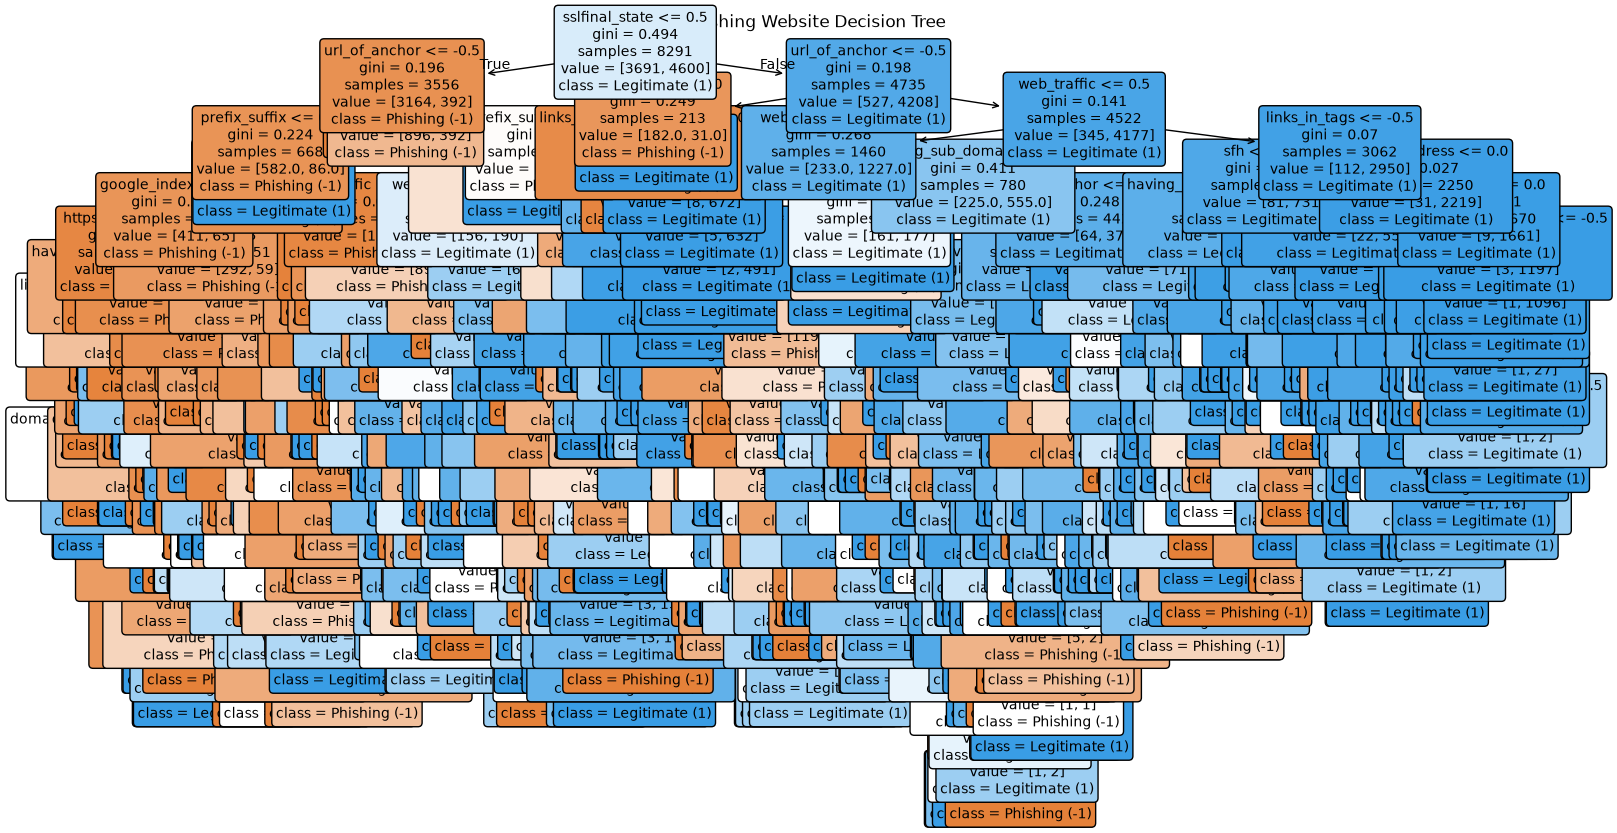

In [19]:
plt.figure(figsize=(18, 10))
plot_tree(
    dtc,
    feature_names=X.columns,
    class_names=["Phishing (-1)", "Legitimate (1)"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Phishing Website Decision Tree")
plt.show()

### Random Forest

In [25]:
rf = RandomForestClassifier(
    random_state=21
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

c:\Users\araz3\anaconda3\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [27]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

          -1       0.98      0.96      0.97      1207
           1       0.97      0.98      0.98      1557

    accuracy                           0.98      2764
   macro avg       0.98      0.97      0.97      2764
weighted avg       0.98      0.98      0.98      2764

